In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import shutil

shutil.copy(
    '/kaggle/input/datasets/sushanthkolakaleti/helper-utils3/helper_utils-3.py',
    '/kaggle/working/helper_utils.py'
)

import helper_utils
torch.manual_seed(45)

In [2]:
# checking for the gpu
if torch.cuda.is_available() :
    device = torch.device("cuda")
    print("Using gpu")
elif torch.backends.mps.is_available() :
    device = torch.device("mps")
    print("Using mps")
else :
    device = torch.device("cpu")
    print("Using cpu")

Using gpu


In [3]:
datapath = './data'

In [4]:
# using tansforms to transform the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081))
])

In [5]:
# Transforming the dataset
train_dataset = torchvision.datasets.MNIST(
    root = datapath,
    download = True,
    train = True,
    transform = transform
)

test_dataset = torchvision.datasets.MNIST(
    root = datapath,
    download = True,
    train = False,
    transform = transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


In [6]:
image , label = train_dataset[0]
print(f"type of the image : {type(image)}")
print(f"shape of the image : {image.shape}")
print(f"Type of the label : {type(label)}")
print(f"The label is  : {label}")

type of the image : <class 'torch.Tensor'>
shape of the image : torch.Size([1, 28, 28])
Type of the label : <class 'int'>
The label is  : 5


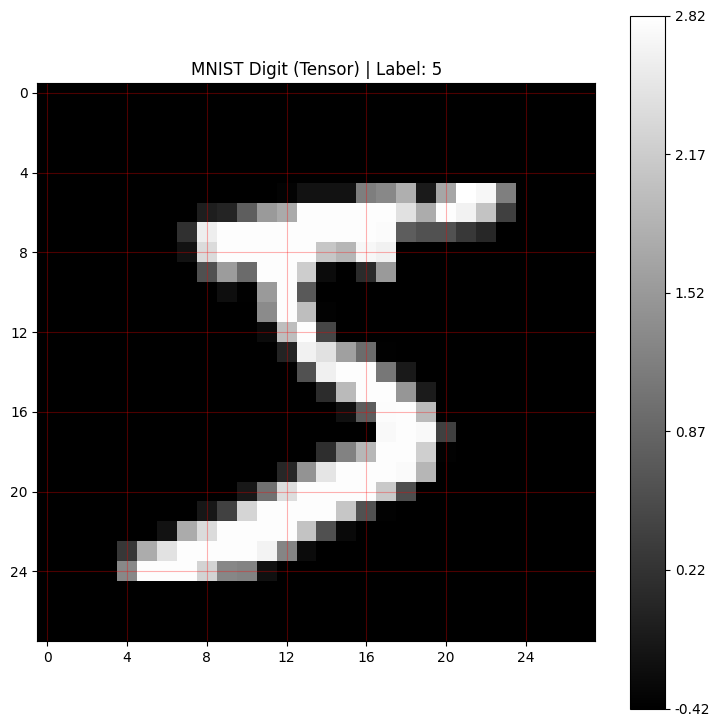

In [7]:
# Visualize the transformed image and its label
helper_utils.display_image(image, label, "MNIST Digit (Tensor)", show_values=False)

In [8]:
# loading the dataset and dividing into batches 
train_dataloader = DataLoader(train_dataset,batch_size = 64,shuffle = True)

test_dataloader = DataLoader(test_dataset,batch_size = 1000,shuffle = False) 

In [9]:
# building the model 
class MNISTmodel(nn.Module) :
    def __init__(self) :
        super(MNISTmodel,self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x) : 
        x = self.flatten(x)
        x = self.layers(x)
        
        return x

In [10]:
# initializing the model,loss_function,optimizer
model = MNISTmodel()

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [11]:
# defining the training function for 1 epoch
def training_epoch(model,loss_fn,optimizer,train_dataloader,device) :
    model = model.to(device)
    
    model.train()
    
    epoch_loss = 0.0
    running_loss = 0.0
    num_correct_predictions = 0
    total_num_predictions = 0
    total_batches = len(train_dataloader)
    
    for batch_idx, (inputs,targets) in enumerate(train_dataloader) :
        # to move the i/ps and targets to the same device as model
        inputs, targets = inputs.to(device), targets.to(device)

        # predicting the outputs of each batch
        outputs = model(inputs)
        
        # calculating the loss of the batch
        loss = loss_fn(outputs,targets)
        # clearing all the accumulated gradients
        optimizer.zero_grad()
        # calculating the gradients wrt parameters
        loss.backward()
        # updating the parameters
        optimizer.step()
        
        loss_value = loss.item()
        running_loss += loss_value # tracks the loss till the required batch
        epoch_loss += loss_value # tracks the loss of all batches
        
        #to know the number of correct predictions
        _,predicted_indices = torch.max(outputs,1)
        batch_size = targets.size(0)
        total_num_predictions = total_num_predictions + batch_size #to know the total number of images predicted till that iteration
        num_correct_in_batch = predicted_indices.eq(targets).sum().item() # correct preds in that 
        num_correct_predictions += num_correct_in_batch # total no of correct preds till that batch
        
        if (batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches :
            # calaculate the avg_loss and accuracy till that batch(i.e for the first time,the avg loss and accuracy of 134 batches is printed)
            avg_running_loss = running_loss/134
            accuracy = 100 * num_correct_predictions/total_num_predictions
            
            print(f"For {batch_idx+1}/{total_batches} ---> Loss : {avg_running_loss:.2f} | Accuracy : {accuracy:.2f}%")
            
            # Reassigning them 0 because for the next 134 batches it should start fresh
            running_loss = 0.0
            total_num_predictions = 0
            num_correct_predictions = 0

    # avg loss for 1 epcch
    avg_epoch_loss = epoch_loss/total_batches

    return model, avg_epoch_loss

In [12]:
# defining the evaluating function 
def evaluate(model,test_loader,device) :
    # setting model into evaluation state
    model.eval()
    # tracks the total number of correct predictions 
    num_correct_predictions = 0
    # tracks the total number of predictions 
    total_num_predictions = 0
    with torch.no_grad() :
        for inputs,targets in test_loader :
            inputs, targets = inputs.to(device), targets.to(device)
            # claculate the predictions 
            outputs = model(inputs)
            #get the class to which the image belongs to 
            _,predicted_indices = torch.max(outputs,1)
            #calculate the total number of corect predictions
            correct_predictions = predicted_indices.eq(targets)
            correct_predictions_batch = correct_predictions.sum().item()
            num_correct_predictions += correct_predictions_batch
            #calculate total number of predictions
            batch_size = targets.size(0)
            total_num_predictions += batch_size

    accuracy = 100 * num_correct_predictions/total_num_predictions
    
    print(f"Accuracy : {accuracy:.2f}")
    
    return accuracy

In [13]:
# training and evaluating the model
epochs = 5

training_loss = [] # tracks training loss of each epoch
test_acc = [] # tracks test accuracy of each epoch

for epoch in range(epochs) :
    print(f"\nTraining epoch {epoch + 1 } :")
    train_model,loss = training_epoch(model,loss_fn,optimizer,train_dataloader,device)

    # storing loss of each epoch
    training_loss.append(loss)
    
    print(f"\nTesting epoch {epoch+1} : ")
    accuracy = evaluate(model,test_dataloader,device)
    # storing the accuracy of each epoch
    test_acc.append(accuracy)


Training epoch 1 :
For 134/938 ---> Loss : 0.55 | Accuracy : 84.19%
For 268/938 ---> Loss : 0.29 | Accuracy : 91.69%
For 402/938 ---> Loss : 0.25 | Accuracy : 92.56%
For 536/938 ---> Loss : 0.20 | Accuracy : 94.20%
For 670/938 ---> Loss : 0.18 | Accuracy : 94.83%
For 804/938 ---> Loss : 0.17 | Accuracy : 94.86%
For 938/938 ---> Loss : 0.15 | Accuracy : 95.65%

Testing epoch 1 : 
Accuracy : 95.99

Training epoch 2 :
For 134/938 ---> Loss : 0.11 | Accuracy : 96.91%
For 268/938 ---> Loss : 0.13 | Accuracy : 96.16%
For 402/938 ---> Loss : 0.11 | Accuracy : 96.74%
For 536/938 ---> Loss : 0.11 | Accuracy : 96.58%
For 670/938 ---> Loss : 0.11 | Accuracy : 96.92%
For 804/938 ---> Loss : 0.11 | Accuracy : 96.65%
For 938/938 ---> Loss : 0.12 | Accuracy : 96.62%

Testing epoch 2 : 
Accuracy : 96.99

Training epoch 3 :
For 134/938 ---> Loss : 0.08 | Accuracy : 97.69%
For 268/938 ---> Loss : 0.09 | Accuracy : 97.01%
For 402/938 ---> Loss : 0.08 | Accuracy : 97.75%
For 536/938 ---> Loss : 0.08 | Ac

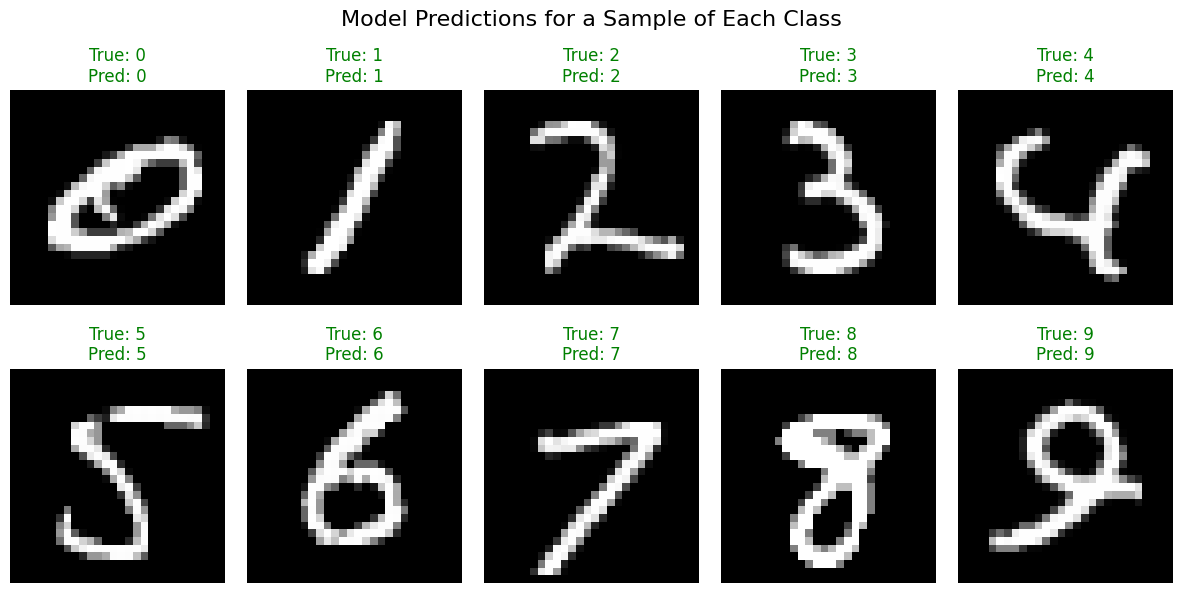

In [14]:
# Visualize model predictions on a random sample of test images
helper_utils.display_predictions(train_model, test_dataloader, device)

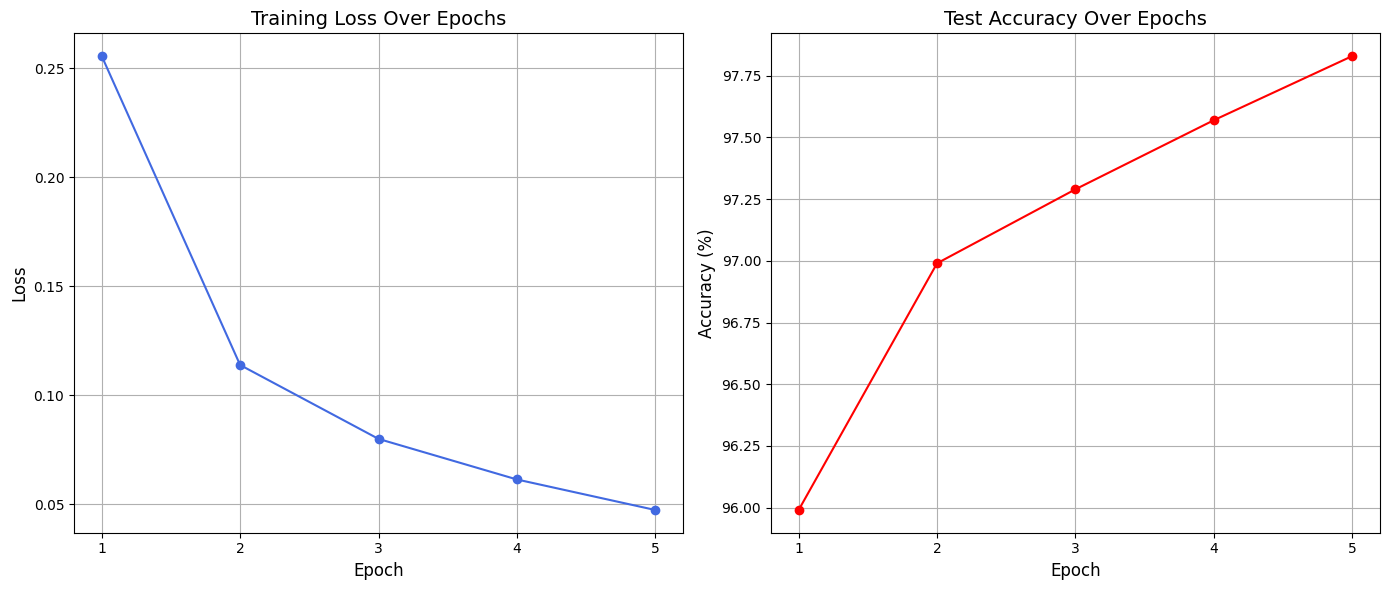

In [15]:
# Plot the training loss and test accuracy curves over all epochs
helper_utils.plot_metrics(training_loss, test_acc)